# The Fallen-Angels premium — a quantitative teardown 🔬
### HAC excess spread · CAPM-style alpha · duration/quality tilt controls · FALN confirmation · half-split decay test · drawdowns & costs · synthetic faithful-engine control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Investable](https://img.shields.io/badge/Tradability-Investable-2ea44f?style=flat-square)
![Just duration + beta?: Busted](https://img.shields.io/badge/Just_duration_%2B_beta%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The fallen-angel premium (Ben Dor & Xu 2011; Ellul-Jotikasthira-Lundblad 2011 for the forced-seller mechanism) is graded here **on the live vehicles only**: ANGL vs HYG/JNK 2012→2026, FALN 2016→ as the independent confirmation, IEF/LQD as tilt controls, BIL as the tradable risk-free. Index-era studies (1997→) are context, never evidence.

> ⚠️ **Data note.** yfinance auto-adjusted closes = **total-return, net-of-fee** ETF tape (ANGL ER 0.35%, HYG 0.49%, FALN 0.25% already inside). As-of **2026-06-30** (last complete month), fingerprint `2009967185e2`. Exactly **one execution lag**: entry at the 2012-04-30 month-end close, returns accrue from 2012-05. Numbers in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fallen_angels_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_prices()                       # sliced to the frozen as-of 2026-06-30
    M = st.monthly_returns(PX)
    MC = st.align_common(M, ["ANGL", "HYG", "JNK", "IEF", "LQD", "BIL"])   # ANGL era
else:
    PX = M = MC = None
print("real ETF cache present:", HAVE_REAL,
      "| ANGL-era months:", (0 if MC is None else len(MC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fingerprint': '2009967185e2', 'start': '2012-05', 'end': '2026-06', 'n_months': 170, 'years': 14.2, 'spread_bps': 18.3, 'spread_t': 2.44, 'spread_pp': 2.18, 'ann': {'ANGL': 6.78, 'HYG': 4.6, 'JNK': 4.51}, 'sharpe': {'ANGL': 0.63, 'HYG': 0.46, 'JNK': 0.43}, 'specs': [('ANGL ~ HYG', 15.03, 2.36, 1.122, None), ('ANGL ~ HYG + IEF', 15.1, 2.38, 1.119, 0.011), ('ANGL ~ HYG + IEF + LQD', 15.83, 2.65, 0.749, -0.445), ('ANGL ~ JNK', 16.7, 2.86, 1.078, None), ('ANGL ~ JNK + IEF', 16.87, 2.92, 1.071, 0.033)], 't_ief': 0.2, 'faln': {'n': 120, 'start': '2016-07', 'spread': 14.16, 'spread_t': 1.64, 'alpha': 9.46, 'alpha_t': 1.43, 'dur_alpha': 7.64, 'dur_t': 1.22}, 'halves': [('2012-05 - 2019-06', 24.77, 2.28, 86), ('2019-07 - 2026-06', 11.68, 1.13, 84)], 'decay_diff': 13.09, 'decay_t': 0.83, 'dd': {'ANGL': -29.3, 'HYG': -22.0}, 'dd_dates': {'ANGL': '2020-02-14 - 2020-03-19', 'HYG': '2020-02-13 - 2020-03-23'}, 'costs': [(2.0, 0.3, 219), (5.0, 0.7, 219), (10.0, 1.4, 218)], 'syn': [(0.0, 5.87, 1.24, 2.61, 0.67), (20.0, 25.87, 5.47, 22.61, 5.78)]}


real ETF cache present: True | ANGL-era months: 170


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | ANGL − HYG = **+18.30 bps/mo** (HAC **t = 2.44**, n = 170); CAPM-style alpha **+15.03 bps/mo** (t = 2.36); alpha t = **2.36–2.92** across all five specs. Caveats: FALN alone t = 1.43; second half alone t = 1.13 (decay not certified, Welch t = 0.83). |
| **Tradability** | `INVESTABLE` | One switch; drag ≤ 1.4 bps/yr vs **+218 bps/yr net**; $3bn AUM, penny spreads, fees inside the tape. Price = risk: β = 1.12, DD **-29.3% vs -22.0%**. |
| **Just duration + beta?** | `BUSTED` | β_IEF = **+0.011 (t = 0.2)** after the HY control — alpha unchanged (+15.03 → +15.10); β_HYG = 1.12 explains ~3 of 18 bps/mo, the rest is alpha. |

> 💡 In plain words: the ejected bonds genuinely out-earn ordinary junk, the extra return is not a duration or beta costume, and the whole thing is collectible in one cheap ETF trade — your compensation for warehousing the forced sellers' inventory and wearing the deeper crash.

## 1 · The claim, steelmanned

IG mandates (insurance RBC rules, IG-only index funds) **must** sell a bond downgraded below BBB−. The supply shock is concentrated around index ejection; the natural buyers (HY funds) are smaller and slower. Prices overshoot; subsequent recovery (plus the rising-star upgrade option) accrues to the holder. Formally, with monthly excess returns $r^e$ over the T-bill (BIL):

$$r^e_{ANGL,t} = \alpha + \beta_{HY}\, r^e_{HYG,t} + \beta_{rate}\, r^e_{IEF,t} + \varepsilon_t$$

- **H₁ (premium exists).** Mean(ANGL − HYG) > 0 with HAC t ≥ 2.
- **H₂ (it's alpha, not tilt).** $\alpha > 0$ with HAC t ≥ 2 **after** the credit-beta and rate-duration controls.
- **H₃ (it's collectible).** The one-switch cost drag is negligible vs the net spread.

We find **all three supported** — with the FALN short-window and second-half caveats stated out loud.

## 2 · So what? — what rides on each answer

The dangerous failure mode of every "smart" bond ETF pitch is a **tilt in costume**: longer duration or higher beta re-labelled as skill. Fallen angels are *specifically* suspect on both counts — they were issued as IG (longer maturities, lower coupons → **longer duration** than original-issue junk) and they enter the portfolio at maximum stress (**higher beta**). So the honesty check is not optional decoration; it *is* the test. If α dies when IEF enters, the premium is a rate bet. If α dies when β is priced, it's leverage. Only the surviving residual earns the stamp.

## 3 · How we'd know — the protocol

- **Tape.** yfinance total-return net-of-fee closes; ANGL-era common sample **2012-05 → 2026-06** (170 months); as-of 2026-06-30; partial months dropped; fingerprint `2009967185e2`.
- **H₁.** HAC (Newey-West, Bartlett, rule-of-thumb lags) t on the monthly ANGL − HYG spread.
- **H₂.** Excess-vs-excess OLS on BIL with NW errors: ANGL ~ HYG, then + IEF (duration), then + LQD (IG credit); benchmark swap to JNK. Five specifications, one bar: t ≥ 2 on α.
- **Confirmation.** FALN (independent issuer + index, 2016-07 →): same battery.
- **Decay.** Pre-registered midpoint split (2019-06); Welch t on the *difference* between halves — a decay claim needs the difference, not one quiet half.
- **Risk & costs.** Daily max-DD comparison; one-switch drag = 2 legs × one-way bps amortised over 14.2 yrs; excess Sharpe race.
- **Machinery proof.** Synthetic world FA = α + 1.05·HY + 0.25·RATE + ε with a planted-α knob: null must stay under t = 2, planted +20 bps/mo must light up. Never market evidence.

## 4 · The teardown

### 4a · H₁ — the raw spread and its HAC t

Cumulative relative strength (ANGL/HYG, log scale) plus the monthly spread's HAC test.

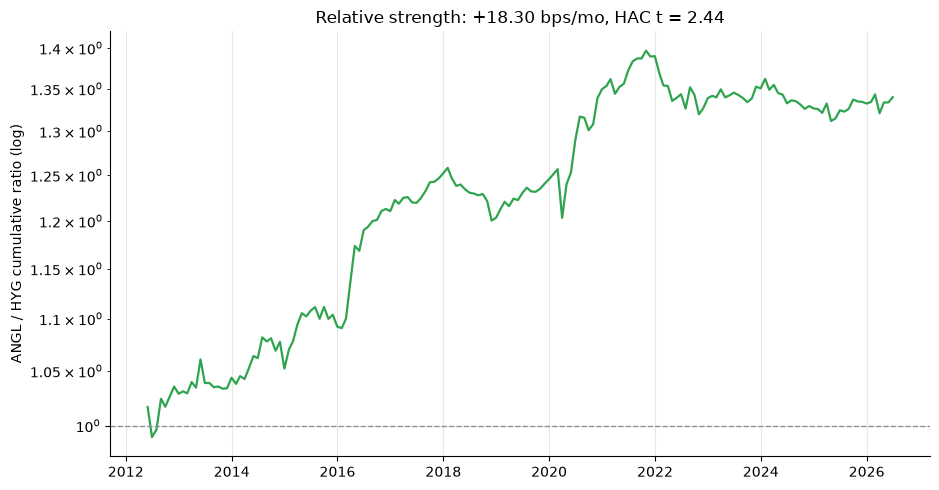

ANGL - HYG: +18.30 bps/mo  HAC t = +2.44  (n=170, lags=4)
annualised: ANGL 6.78%  HYG 4.60%
excess Sharpe (rf=BIL): ANGL 0.63  HYG 0.46  JNK 0.43


In [2]:
if HAVE_REAL:
    diff = (MC['ANGL'] - MC['HYG']).dropna()
    h = st.hac_mean(diff)
    rel = (1 + MC[['ANGL','HYG']]).cumprod()
    ratio = rel['ANGL'] / rel['HYG']
    fig, ax = plt.subplots()
    ax.plot(ratio.index, ratio, c=GREEN, lw=1.6)
    ax.axhline(1.0, c=GREY, ls='--', lw=1)
    ax.set_yscale('log'); ax.set_ylabel('ANGL / HYG cumulative ratio (log)')
    ax.set_title(f"Relative strength: +{h['alpha_bps']:.2f} bps/mo, HAC t = {h['t_alpha']:.2f}")
    plt.tight_layout(); plt.show()
    print(f"ANGL - HYG: {h['alpha_bps']:+.2f} bps/mo  HAC t = {h['t_alpha']:+.2f}  "
          f"(n={h['n']}, lags={h['lags']})")
    print(f"annualised: ANGL {st.ann_return(MC['ANGL']):.2f}%  HYG {st.ann_return(MC['HYG']):.2f}%")
    print(f"excess Sharpe (rf=BIL): ANGL {st.sharpe_excess(MC,'ANGL'):.2f}  "
          f"HYG {st.sharpe_excess(MC,'HYG'):.2f}  JNK {st.sharpe_excess(MC,'JNK'):.2f}")
else:
    print('cache missing - frozen:', R['spread_bps'], R['spread_t'], R['sharpe'])

> 💡 In plain words: **+18.30 bps/mo** for 14.2 years at **HAC t = 2.44** — the gap is persistent, not one lucky year (the ratio chart climbs through most of the sample, with the 2020 downgrade wave as the big step). Excess Sharpe race: ANGL **0.63** vs HYG **0.46** — better *risk-adjusted*, not just higher-octane.

### 4b · H₂ — the alpha gauntlet (five specifications)

Excess-vs-excess NW regressions. The tilt hypotheses get every chance to kill the alpha: rate duration (IEF), IG credit (LQD), benchmark swap (JNK).

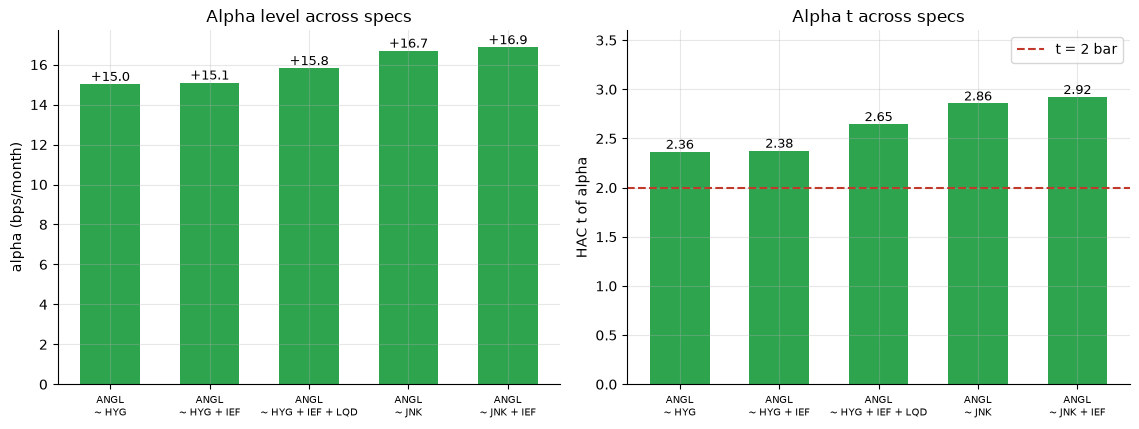

ANGL ~ HYG                 alpha +15.03 bps/mo  HAC t +2.36
ANGL ~ HYG + IEF           alpha +15.10 bps/mo  HAC t +2.38
ANGL ~ HYG + IEF + LQD     alpha +15.83 bps/mo  HAC t +2.65
ANGL ~ JNK                 alpha +16.70 bps/mo  HAC t +2.86
ANGL ~ JNK + IEF           alpha +16.87 bps/mo  HAC t +2.92


In [3]:
if HAVE_REAL:
    specs = [('ANGL ~ HYG',             st.capm_alpha(MC,'ANGL','HYG')),
             ('ANGL ~ HYG + IEF',       st.factor_alpha(MC,'ANGL',['HYG','IEF'])),
             ('ANGL ~ HYG + IEF + LQD', st.factor_alpha(MC,'ANGL',['HYG','IEF','LQD'])),
             ('ANGL ~ JNK',             st.capm_alpha(MC,'ANGL','JNK')),
             ('ANGL ~ JNK + IEF',       st.factor_alpha(MC,'ANGL',['JNK','IEF']))]
    rows = [(lab, r['alpha_bps'], r['t_alpha']) for lab, r in specs]
else:
    rows = [(s[0], s[1], s[2]) for s in R['specs']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4))
x = np.arange(len(rows))
a1.bar(x, [r[1] for r in rows], color=GREEN, width=.6)
for i, r in enumerate(rows): a1.annotate(f'{r[1]:+.1f}', (i, r[1]), ha='center', va='bottom', fontsize=9)
a1.set_xticks(x); a1.set_xticklabels([r[0].replace(' ~ ','\n~ ') for r in rows], fontsize=7.5)
a1.set_ylabel('alpha (bps/month)'); a1.set_title('Alpha level across specs')
a2.bar(x, [r[2] for r in rows], color=GREEN, width=.6)
a2.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, r in enumerate(rows): a2.annotate(f'{r[2]:.2f}', (i, r[2]), ha='center', va='bottom', fontsize=9)
a2.set_xticks(x); a2.set_xticklabels([r[0].replace(' ~ ','\n~ ') for r in rows], fontsize=7.5)
a2.set_ylabel('HAC t of alpha'); a2.set_ylim(0, 3.6); a2.set_title('Alpha t across specs'); a2.legend()
plt.tight_layout(); plt.show()
for lab, a, t in rows: print(f'{lab:26s} alpha {a:+6.2f} bps/mo  HAC t {t:+.2f}')

> 💡 In plain words: the alpha sits at **+15 to +17 bps/mo with t = 2.36–2.92 in all five specs**. The duration factor is dead on arrival (β_IEF = +0.011, t = 0.2) — fallen angels *do* run longer duration in yield terms, but over this sample the HY factor already absorbs it. The honest deduction is beta: β_HYG = 1.12 converts ~3 bps/mo of the raw spread into priced risk. What's left is the forced-seller alpha.

### 4c · Confirmation & decay — FALN and the half-split

An independent issuer/index (FALN, 2016-07 →) and a pre-registered midpoint split of the ANGL − HYG spread. A decay claim needs a significant *difference* between halves.

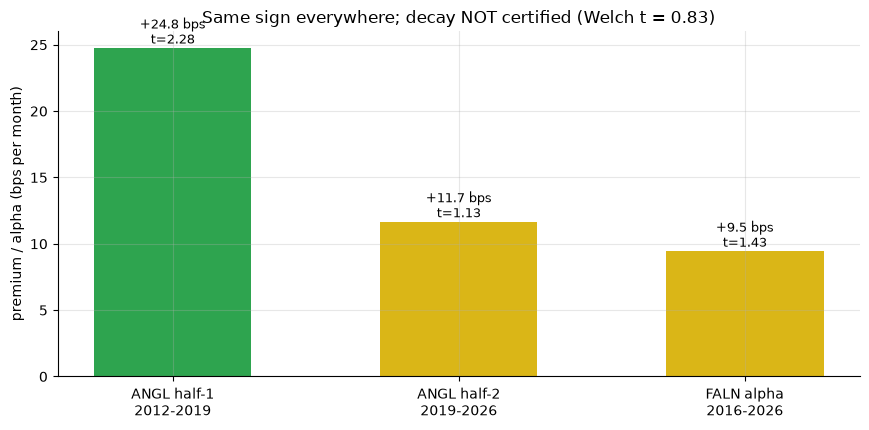

half-1 +24.77 (t=2.28)  half-2 +11.68 (t=1.13)
decay test: diff +13.09 bps/mo  Welch t = +0.83
FALN alpha +9.46 bps/mo (t=1.43)


In [4]:
if HAVE_REAL:
    mf = st.align_common(M, ['FALN','HYG','IEF','BIL'])
    cf = st.capm_alpha(mf, 'FALN', 'HYG')
    diff = (MC['ANGL'] - MC['HYG']).dropna()
    h1, h2 = diff.loc[:'2019-06-30'], diff.loc['2019-07-01':]
    s1, s2 = st.hac_mean(h1), st.hac_mean(h2)
    wt = st.welch_t(h1, h2)
    vals = [(f'ANGL half-1\n2012-2019', s1['alpha_bps'], s1['t_alpha']),
            (f'ANGL half-2\n2019-2026', s2['alpha_bps'], s2['t_alpha']),
            ('FALN alpha\n2016-2026', cf['alpha_bps'], cf['t_alpha'])]
    decay = (wt['diff_bps'], wt['t'])
else:
    vals = [('ANGL half-1\n2012-2019', R['halves'][0][1], R['halves'][0][2]),
            ('ANGL half-2\n2019-2026', R['halves'][1][1], R['halves'][1][2]),
            ('FALN alpha\n2016-2026', R['faln']['alpha'], R['faln']['alpha_t'])]
    decay = (R['decay_diff'], R['decay_t'])
fig, ax = plt.subplots(figsize=(8.8, 4.4))
cols = [GREEN if v[2] >= 2 else AMBER for v in vals]
ax.bar([v[0] for v in vals], [v[1] for v in vals], color=cols, width=.55)
for i, v in enumerate(vals): ax.annotate(f'{v[1]:+.1f} bps\nt={v[2]:.2f}', (i, v[1]), ha='center', va='bottom', fontsize=9)
ax.set_ylabel('premium / alpha (bps per month)')
ax.set_title(f'Same sign everywhere; decay NOT certified (Welch t = {decay[1]:.2f})')
plt.tight_layout(); plt.show()
print(f'half-1 {vals[0][1]:+.2f} (t={vals[0][2]:.2f})  half-2 {vals[1][1]:+.2f} (t={vals[1][2]:.2f})')
print(f'decay test: diff {decay[0]:+.2f} bps/mo  Welch t = {decay[1]:+.2f}')
print(f'FALN alpha {vals[2][1]:+.2f} bps/mo (t={vals[2][2]:.2f})')

> 💡 In plain words: every window points the **same way**, but only the full ANGL tape certifies. The second half (+11.7 bps/mo, t = 1.13) and FALN (+9.5 bps/mo, t = 1.43) are positive but under the bar alone — and the half-to-half difference is pure noise (Welch t = 0.83). The premium is **episodic** (it needs downgrade waves: 2016 energy, 2020 COVID), which is exactly what an un-decayed but bursty structural premium should look like. We say the caveat out loud rather than certify decay we can't show.

### 4d · Risk & costs — what you pay, in both currencies

The drawdown bill (daily, total-return) and the friction bill (one switch, 2 legs).

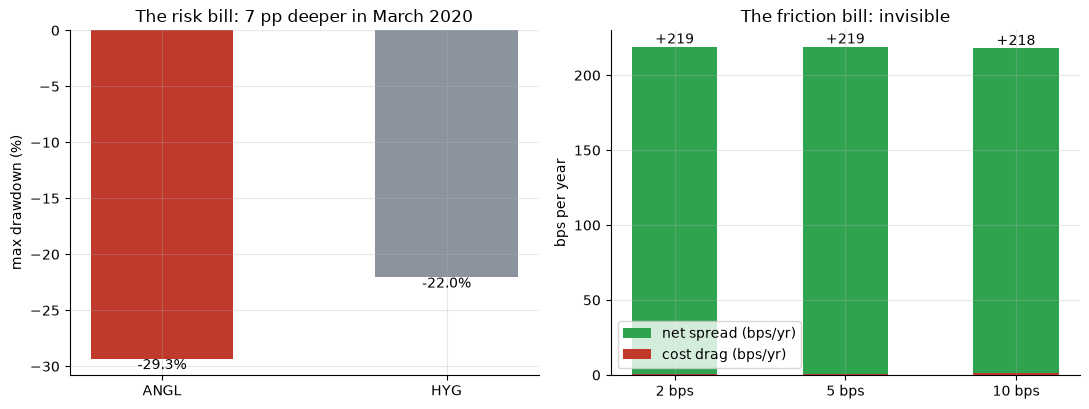

max DD: ANGL -29.3%  HYG -22.0%
  2.0 bps one-way: drag 0.3 bps/yr -> net +219 bps/yr
  5.0 bps one-way: drag 0.7 bps/yr -> net +219 bps/yr
 10.0 bps one-way: drag 1.4 bps/yr -> net +218 bps/yr


In [5]:
if HAVE_REAL:
    dd_a = st.max_drawdown(PX['ANGL'].loc['2012-04-11':])
    dd_h = st.max_drawdown(PX['HYG'].loc['2012-04-11':])
    dd_pair = (dd_a['depth_pct'], dd_h['depth_pct'])
else:
    dd_pair = (R['dd']['ANGL'], R['dd']['HYG'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.2))
a1.bar(['ANGL', 'HYG'], dd_pair, color=[RED, GREY], width=.5)
for i, v in enumerate(dd_pair): a1.annotate(f'{v:.1f}%', (i, v), ha='center', va='top')
a1.set_ylabel('max drawdown (%)'); a1.set_title('The risk bill: 7 pp deeper in March 2020')
cost_x = [f'{c[0]:.0f} bps' for c in R['costs']]
a2.bar(cost_x, [c[2] for c in R['costs']], color=GREEN, width=.5, label='net spread (bps/yr)')
a2.bar(cost_x, [c[1] for c in R['costs']], color=RED, width=.5, label='cost drag (bps/yr)')
for i, c in enumerate(R['costs']): a2.annotate(f'+{c[2]}', (i, c[2]), ha='center', va='bottom')
a2.set_ylabel('bps per year'); a2.set_title('The friction bill: invisible'); a2.legend()
plt.tight_layout(); plt.show()
print(f'max DD: ANGL {dd_pair[0]:.1f}%  HYG {dd_pair[1]:.1f}%')
for c in R['costs']: print(f'{c[0]:>5.1f} bps one-way: drag {c[1]:.1f} bps/yr -> net {c[2]:+d} bps/yr')

> 💡 In plain words: the strategy is a **single substitution** held for years, so even 10 bps one-way costs 1.4 bps/yr against a **+218 bps/yr** net spread — friction is irrelevant, which is why this earns `INVESTABLE`. The real bill is the **-29% vs -22%** drawdown: you are the warehouse for the forced sellers' inventory precisely when everything is on fire.

### 4e · Faithful-engine control — we know the truth here

A deterministic world FA = α + 1.05·HY + 0.25·RATE + ε with a planted-α knob. The pipeline must NOT manufacture alpha from the null and MUST recover a planted +20 bps/mo.

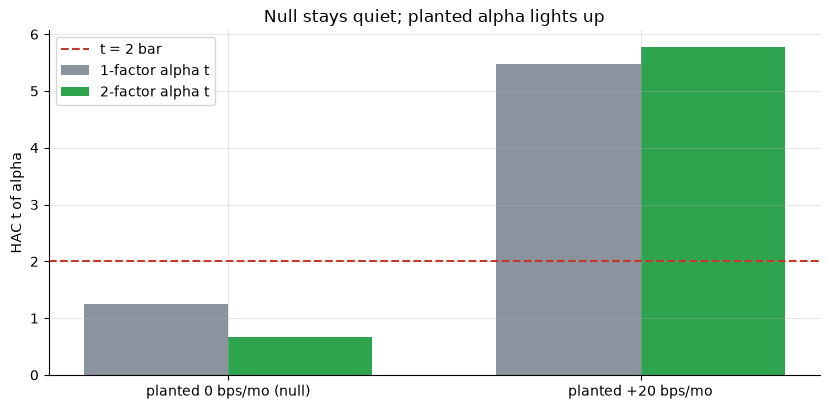

planted  +0.0: 1f alpha +5.87 (t=+1.24)  2f alpha +2.61 (t=+0.67)
planted +20.0: 1f alpha +25.87 (t=+5.47)  2f alpha +22.61 (t=+5.78)


In [6]:
res = []
for planted in (0.0, 20.0):
    w = data.synthetic_world(alpha_bps=planted, seed=610)
    r1 = st.nw_ols(w['FA'], w[['HY']])
    r2 = st.nw_ols(w['FA'], w[['HY','RATE']])
    res.append((planted, r1['alpha_bps'], r1['t_alpha'], r2['alpha_bps'], r2['t_alpha']))
fig, ax = plt.subplots(figsize=(8.4, 4.2))
x = np.arange(2); wdt = 0.35
ax.bar(x - wdt/2, [r[2] for r in res], wdt, color=GREY, label='1-factor alpha t')
ax.bar(x + wdt/2, [r[4] for r in res], wdt, color=GREEN, label='2-factor alpha t')
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
ax.set_xticks(x); ax.set_xticklabels(['planted 0 bps/mo (null)', 'planted +20 bps/mo'])
ax.set_ylabel('HAC t of alpha'); ax.set_title('Null stays quiet; planted alpha lights up'); ax.legend()
plt.tight_layout(); plt.show()
for p, a1_, t1, a2_, t2 in res:
    print(f'planted {p:+5.1f}: 1f alpha {a1_:+.2f} (t={t1:+.2f})  2f alpha {a2_:+.2f} (t={t2:+.2f})')

> 💡 In plain words: with **zero** planted alpha the machinery reads t = 1.24/0.67 (quiet); with **+20 bps/mo** planted it reads t ≈ 5.5–5.8 (loud). The HAC-alpha pipeline is faithful and does not hallucinate. *(A machinery proof only — never cited in support of the real-tape stamps.)*

## 5 · The verdict

- **Signal `REAL`** — ANGL − HYG **+18.30 bps/mo** (HAC **t = 2.44**, n = 170); alpha **+15.03 bps/mo at t = 2.36**, holding at **t = 2.36–2.92** across HYG/JNK ± IEF ± LQD. Clears **t ≥ 2** on the tape in every specification. Caveats named: FALN alone t = 1.43 (same sign, shorter window), second half alone t = 1.13, decay not certified (Welch t = 0.83).
- **Tradability `INVESTABLE`** — one ETF switch; drag ≤ 1.4 bps/yr vs **+218 bps/yr net**; $3bn AUM, penny spreads, fees inside the tape. The admission price is risk (β = 1.12, DD -29.3% vs -22.0%), not friction.
- **Just duration + beta? `BUSTED`** — β_IEF = +0.011 (t = 0.2), alpha unchanged when the rate factor enters; β_HYG = 1.12 converts only ~3 of 18 bps/mo into priced risk. The forced-seller mechanism, not a tilt costume, is what the tape supports.

## 6 · Going further

- **The mechanism has an owner.** Ellul et al. (2011) trace the fire sales to insurance capital rules — a *regulatory* seller that cannot learn its way out of the trade. That's why 14 years of ETF assets haven't closed it: the supply of forced sellers is policy, not opinion.
- **Watch the raw material.** The premium needs downgrade waves. A long quiet-credit regime idles it (the 2019→2026 half alone is t = 1.13); a recession mints it. Sizing it as a permanent overweight means accepting years of nothing.
- **The index-vs-live gap.** Index studies since 1997 show bigger numbers than +2.2 pp/yr — index math pays no fees and assumes frictionless rebalancing into the most dislocated bonds. The live, fee-paying, capacity-constrained version is the only one this desk grades — and it still clears.
- **Siblings:** [Study 115 — Credit-Spreads](../../115-credit-spreads/) (credit as an *equity timing* signal — fails) and [Study 340 — Bank-Loans](../../340-bank-loans/) (duration swapped for credit risk — a costume this study's controls are built to catch).

*The reproducible core is offline and deterministic; every number above is printed by [`examples/verify.py`](../examples/verify.py) and frozen in [`docs/results.md`](../docs/results.md).*